# Hybrid Methods on the Shared Validation Split

This notebook compares the original baselines, pure ML models, and two hybrid routes:
- `Hybrid-QPResidual`: QP-GP residual correction
- `Hybrid-CNNFusion`: CNN + baseline/statistical feature fusion

All plots use the same 90 validation stars.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlepad'] = 10
plt.rcParams['grid.alpha'] = 0.18
plt.rcParams['grid.linestyle'] = ':'

PRED_PATH = Path(r'D:/Dissertation/backup/data/kepler/models/shared_val_extended_predictions.csv')
SUMMARY_PATH = Path(r'D:/Dissertation/backup/data/kepler/models/shared_val_extended_summary.csv')
QP_IMP_PATH = Path(r'D:/Dissertation/backup/data/kepler/models/hybrid_qpgp_residual/hybrid_qpgp_residual_feature_importance.csv')
CNN_IMP_PATH = Path(r'D:/Dissertation/backup/data/kepler/models/hybrid_cnn_fusion/hybrid_cnn_fusion_feature_importance.csv')

pred_df = pd.read_csv(PRED_PATH)
summary_df = pd.read_csv(SUMMARY_PATH)
qp_imp = pd.read_csv(QP_IMP_PATH)
cnn_imp = pd.read_csv(CNN_IMP_PATH)

palette = {
    'Hybrid-QPResidual': '#2A9D8F',
    'Hybrid-CNNFusion': '#F4A261',
    'QP-GP': '#8172B2',
    'CNN': '#55A868',
    'LightPred': '#4C72B0',
    'LSTM': '#C44E52',
    'GPS': '#64B96A',
    'LS': '#64B5CD',
}
focus_order = ['Hybrid-QPResidual', 'Hybrid-CNNFusion', 'QP-GP', 'CNN', 'LightPred', 'LSTM']

## Summary Table

In [2]:
cols = ['method', 'N', 'MAE', 'RMSE', 'MedianAbsErr', 'Bias', 'Frac(<10%)', 'Frac(<20%)', 'Corr', 'best_estimator', 'cv_mae']
display(summary_df[cols].sort_values('MAE').round(4).reset_index(drop=True))

,method,N,MAE,RMSE,MedianAbsErr,Bias,Frac(<10%),Frac(<20%),Corr,best_estimator,cv_mae
0,ACF,10,0.3743,0.5520,0.2308,-0.3743,1.0000,1.0000,0.9998,NaN,NaN
1,Hybrid-QPResidual,90,1.6865,2.9661,0.4536,-0.2958,0.7444,0.8889,0.9588,RandomForestRegressor,1.4064
2,Hybrid-CNNFusion,90,1.7577,2.9188,0.7113,-0.2979,0.6333,0.8778,0.9606,RandomForestRegressor,1.5186
3,QP-GP,90,3.9749,6.2244,2.4163,3.9163,0.3556,0.6667,0.9377,NaN,NaN
4,CNN,90,6.2329,8.2708,4.1811,-0.8501,0.2556,0.4222,0.6168,NaN,NaN
5,LSTM,90,8.4417,10.3349,7.4751,-0.2907,0.1667,0.3444,0.0725,NaN,NaN
6,LightPred,90,9.3178,11.1357,8.3906,-3.6862,0.1000,0.1778,0.1092,NaN,NaN
7,GPS,87,10.3768,13.6430,6.7738,7.2035,0.1149,0.4713,0.3112,NaN,NaN
8,LS,90,17.8885,21.4026,20.2242,17.8167,0.1778,0.2111,0.2912,NaN,NaN


## Label vs Prediction

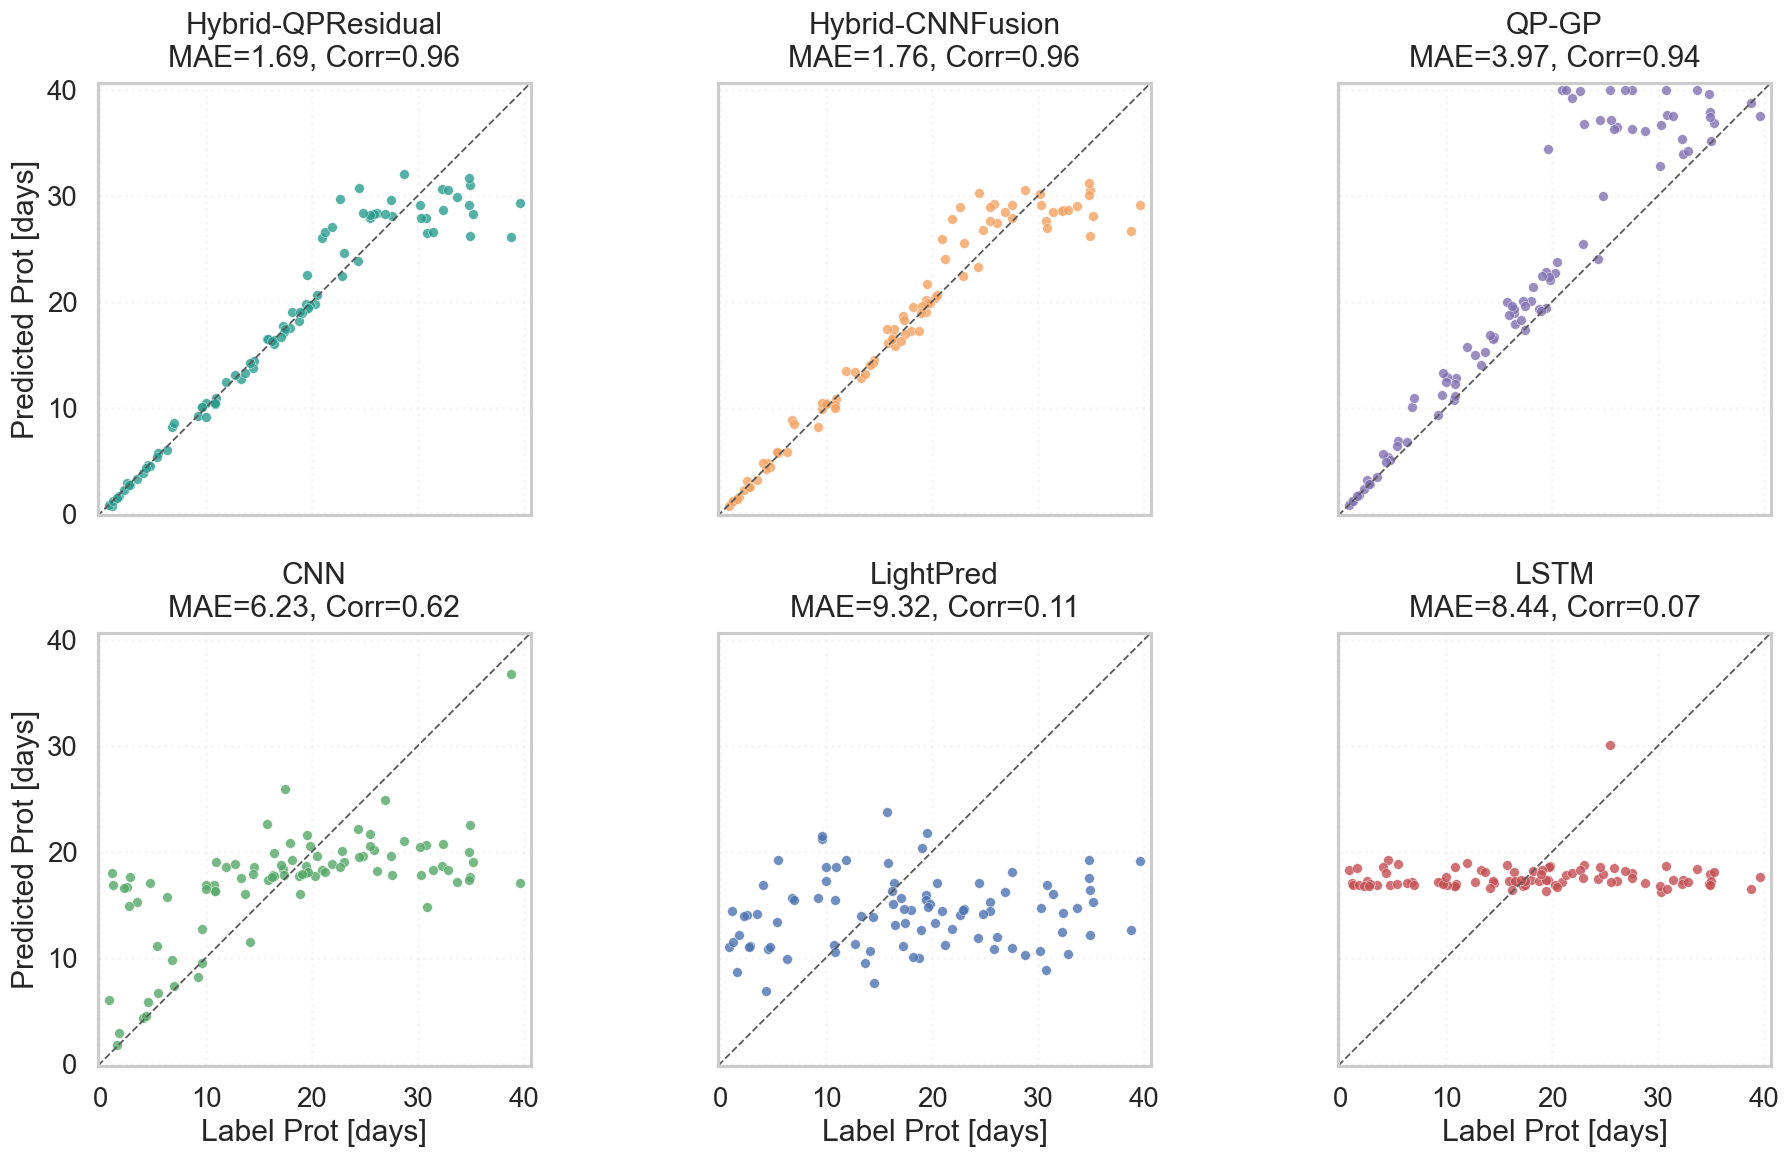

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16.5, 10.0), sharex=True, sharey=True)
axes = axes.ravel()
for ax, method in zip(axes, focus_order):
    plot_df = pred_df[['prot_label', method]].replace([np.inf, -np.inf], np.nan).dropna()
    sns.scatterplot(
        data=plot_df,
        x='prot_label',
        y=method,
        s=34,
        alpha=0.8,
        edgecolor='white',
        linewidth=0.3,
        color=palette[method],
        ax=ax,
    )
    lim_min = min(plot_df['prot_label'].min(), plot_df[method].min())
    lim_max = max(plot_df['prot_label'].max(), plot_df[method].max())
    lims = [lim_min - 1, lim_max + 1]
    ax.plot(lims, lims, linestyle='--', color='0.35', linewidth=1.1)
    row = summary_df[summary_df['method'] == method].iloc[0]
    ax.set_title(f"{method}\nMAE={row['MAE']:.2f}, Corr={row['Corr']:.2f}")
    ax.set_xlabel('Label Prot [days]')
    ax.set_ylabel('Predicted Prot [days]')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', 'box')
plt.tight_layout()
plt.show()

## Relative Error ECDF

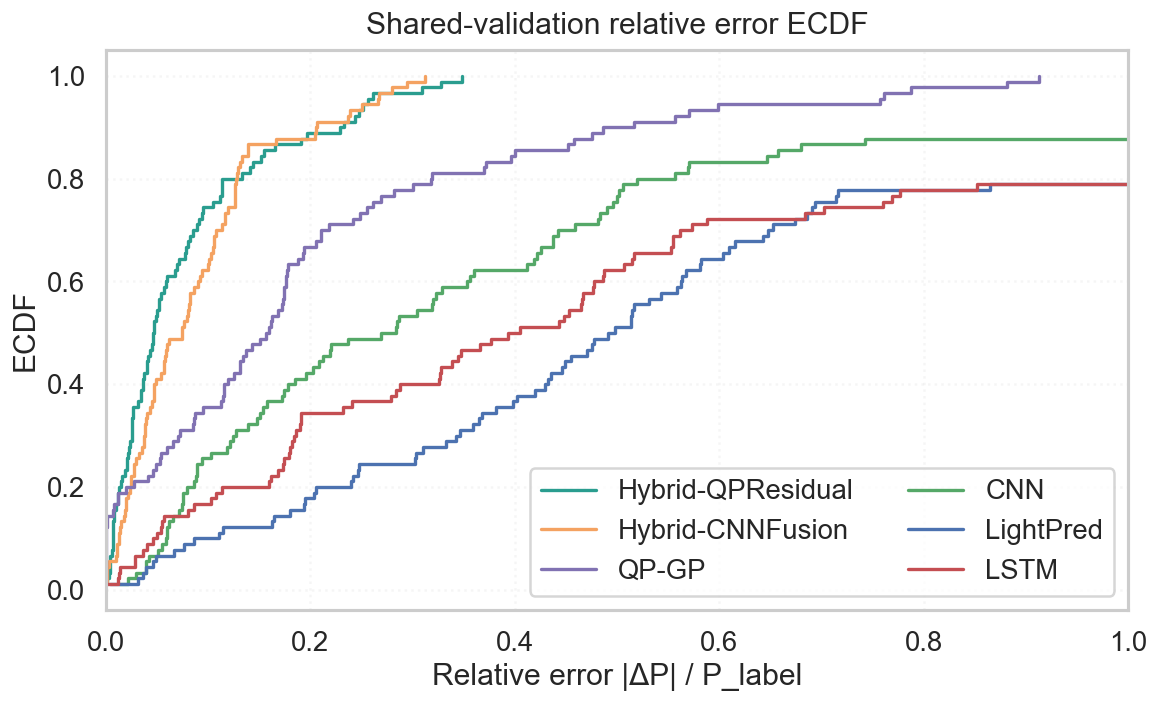

In [4]:
fig, ax = plt.subplots(figsize=(10.0, 6.2))
for method in focus_order:
    plot_df = pred_df[['prot_label', method]].replace([np.inf, -np.inf], np.nan).dropna()
    rel = ((plot_df[method] - plot_df['prot_label']).abs() / plot_df['prot_label']).sort_values().to_numpy()
    y = np.arange(1, len(rel) + 1) / len(rel)
    ax.step(rel, y, where='post', linewidth=2.0, label=method, color=palette[method])
ax.set_xlim(0, 1.0)
ax.set_xlabel('Relative error |ΔP| / P_label')
ax.set_ylabel('ECDF')
ax.set_title('Shared-validation relative error ECDF')
ax.legend(frameon=True, ncol=2)
plt.tight_layout()
plt.show()

## Improvement Over QP-GP

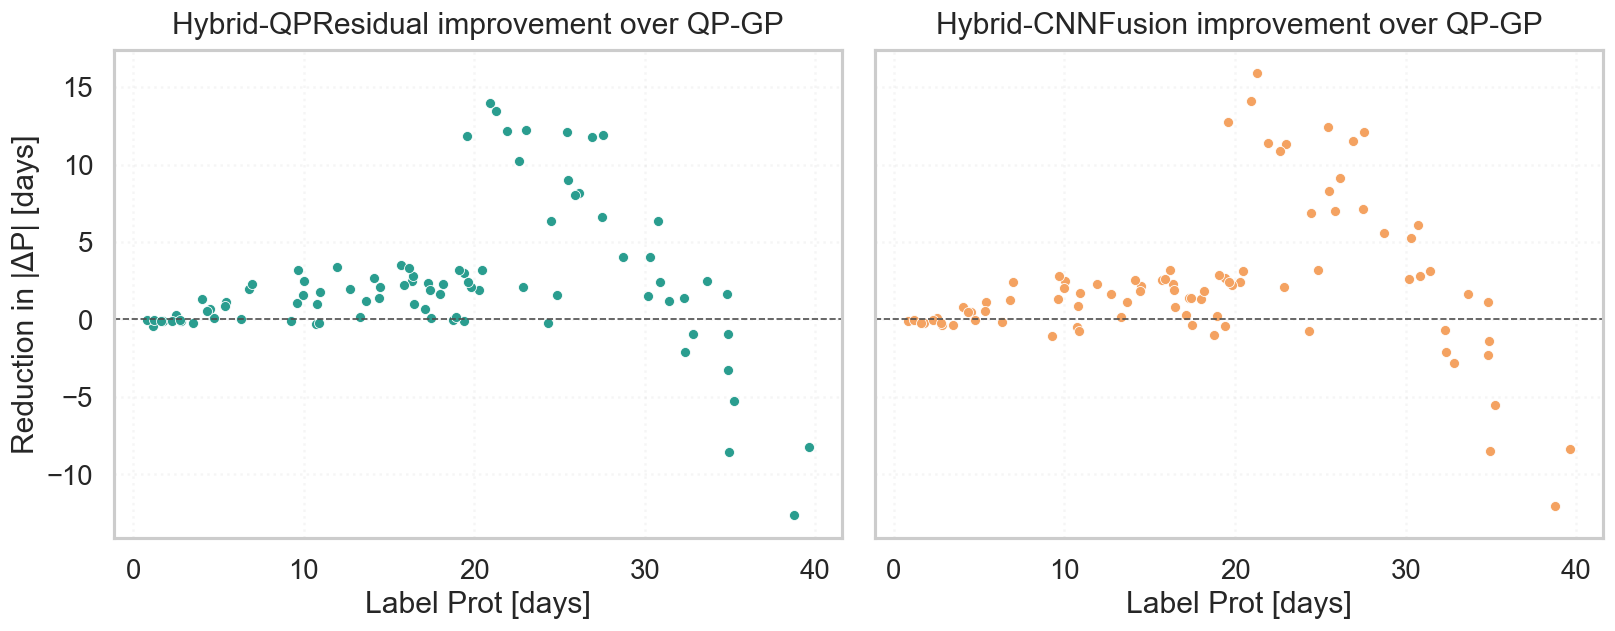

In [5]:
improve_df = pred_df[['prot_label', 'QP-GP', 'Hybrid-QPResidual', 'Hybrid-CNNFusion']].copy()
improve_df['qpgp_abs_err'] = (improve_df['QP-GP'] - improve_df['prot_label']).abs()
improve_df['hybrid_qp_abs_err'] = (improve_df['Hybrid-QPResidual'] - improve_df['prot_label']).abs()
improve_df['hybrid_cnn_abs_err'] = (improve_df['Hybrid-CNNFusion'] - improve_df['prot_label']).abs()
improve_df['qp_improvement'] = improve_df['qpgp_abs_err'] - improve_df['hybrid_qp_abs_err']
improve_df['cnn_improvement'] = improve_df['qpgp_abs_err'] - improve_df['hybrid_cnn_abs_err']

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.6), sharey=True)
sns.scatterplot(data=improve_df, x='prot_label', y='qp_improvement', s=36, color=palette['Hybrid-QPResidual'], ax=axes[0])
axes[0].axhline(0.0, linestyle='--', linewidth=1.0, color='0.3')
axes[0].set_title('Hybrid-QPResidual improvement over QP-GP')
axes[0].set_xlabel('Label Prot [days]')
axes[0].set_ylabel('Reduction in |ΔP| [days]')

sns.scatterplot(data=improve_df, x='prot_label', y='cnn_improvement', s=36, color=palette['Hybrid-CNNFusion'], ax=axes[1])
axes[1].axhline(0.0, linestyle='--', linewidth=1.0, color='0.3')
axes[1].set_title('Hybrid-CNNFusion improvement over QP-GP')
axes[1].set_xlabel('Label Prot [days]')
axes[1].set_ylabel('Reduction in |ΔP| [days]')
plt.tight_layout()
plt.show()

## Feature Importance

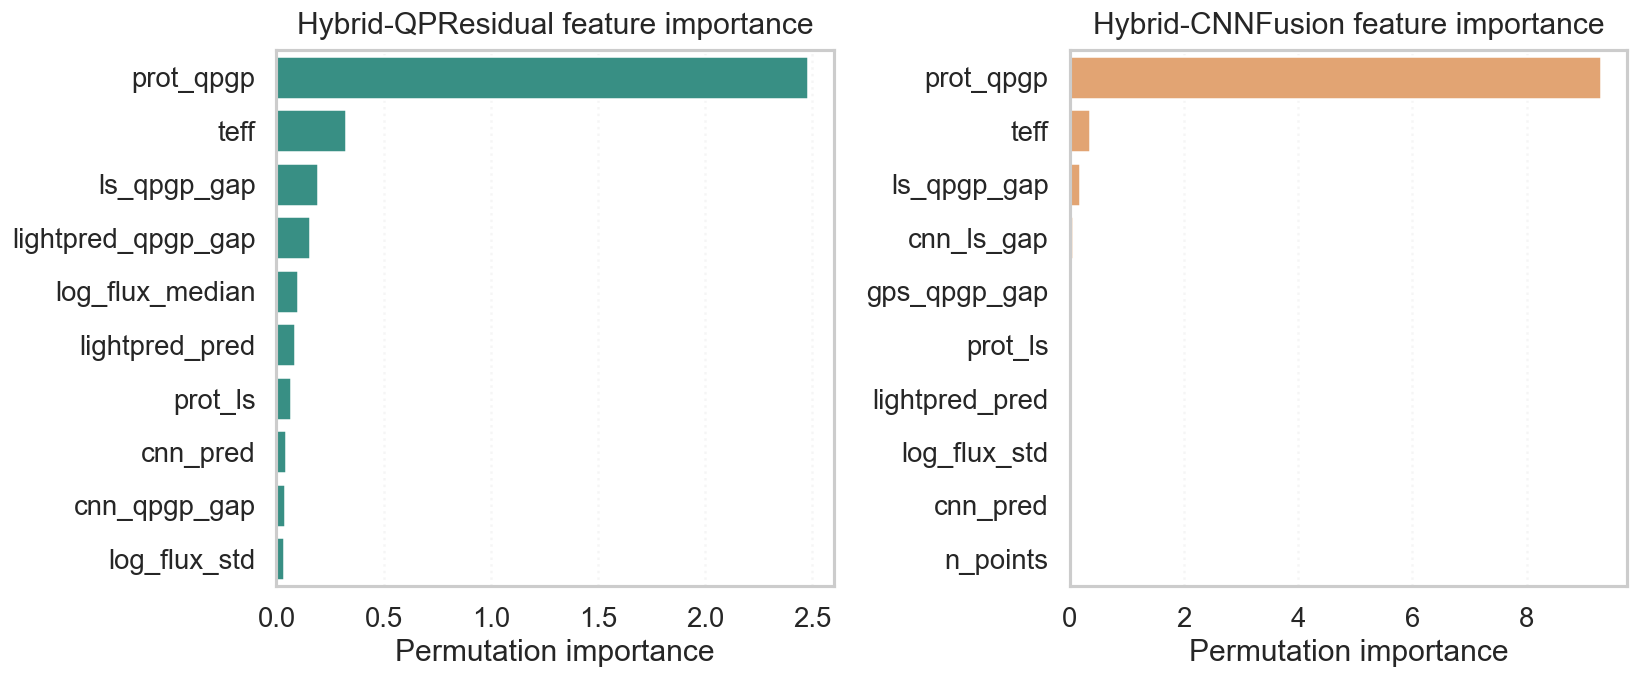

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 6.0))

qp_top = qp_imp.sort_values('importance_mean', ascending=False).head(10)
sns.barplot(data=qp_top, x='importance_mean', y='feature', color=palette['Hybrid-QPResidual'], ax=axes[0])
axes[0].set_title('Hybrid-QPResidual feature importance')
axes[0].set_xlabel('Permutation importance')
axes[0].set_ylabel('')

cnn_top = cnn_imp.sort_values('importance_mean', ascending=False).head(10)
sns.barplot(data=cnn_top, x='importance_mean', y='feature', color=palette['Hybrid-CNNFusion'], ax=axes[1])
axes[1].set_title('Hybrid-CNNFusion feature importance')
axes[1].set_xlabel('Permutation importance')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()